In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, RocCurveDisplay, confusion_matrix, recall_score, precision_score
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

In [41]:
le = LabelEncoder()
ohe = OneHotEncoder()

# Load the dataset

In [42]:
df = pd.read_csv("./train.csv")

df.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


In [43]:
test = pd.read_csv("./test.csv")

test.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,58645,23,69000,RENT,3.0,HOMEIMPROVEMENT,F,25000,15.76,0.36,N,2
1,58646,26,96000,MORTGAGE,6.0,PERSONAL,C,10000,12.68,0.10,Y,4
2,58647,26,30000,RENT,5.0,VENTURE,E,4000,17.19,0.13,Y,2
3,58648,33,50000,RENT,4.0,DEBTCONSOLIDATION,A,7000,8.90,0.14,N,7
4,58649,26,102000,MORTGAGE,8.0,HOMEIMPROVEMENT,D,15000,16.32,0.15,Y,4


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          58645 non-null  int64  
 1   person_age                  58645 non-null  int64  
 2   person_income               58645 non-null  int64  
 3   person_home_ownership       58645 non-null  object 
 4   person_emp_length           58645 non-null  float64
 5   loan_intent                 58645 non-null  object 
 6   loan_grade                  58645 non-null  object 
 7   loan_amnt                   58645 non-null  int64  
 8   loan_int_rate               58645 non-null  float64
 9   loan_percent_income         58645 non-null  float64
 10  cb_person_default_on_file   58645 non-null  object 
 11  cb_person_cred_hist_length  58645 non-null  int64  
 12  loan_status                 58645 non-null  int64  
dtypes: float64(3), int64(6), object

As we can see we don't have any missing values for this dataset.

# Drop duplicated data

In [45]:
print(df.shape)
df.drop_duplicates()
print(df.shape)

(58645, 13)
(58645, 13)


# Make preprocessing function

In [90]:
def preprocess(dataframe : pd.DataFrame):
    df = dataframe.copy()
    
    # Drop id column
    df = df.drop(columns=["id"], errors="ignore")
    
    #Drop age and cb person hist length
    df = df.drop(columns=["cb_person_cred_hist_length", "person_age", "person_income"])
    
    # Label Encoding
    df["loan_grade"] = df["loan_grade"].map({
        "A": 6, "B": 5, "C": 4, "D": 3, "E": 2, "F": 1, "G": 0
    })
    
    df["cb_person_default_on_file"] = df["cb_person_default_on_file"].map({
        "Y": 1, "N": 0
    })
    
    # One Hot Encoding
    df = pd.get_dummies(df, columns=["person_home_ownership", "loan_intent"], dtype=int)
    
    return df

# Histogram plot for all numerical column

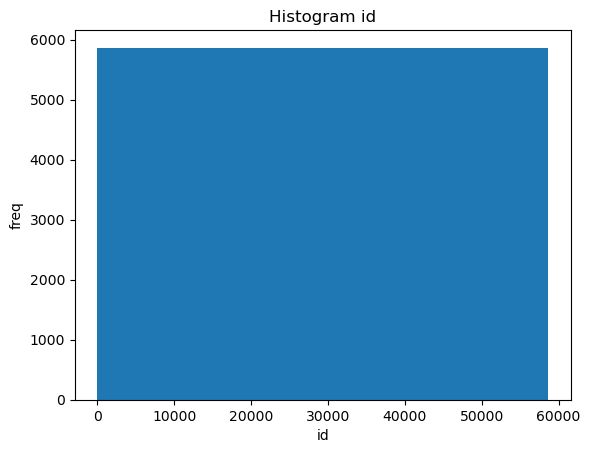

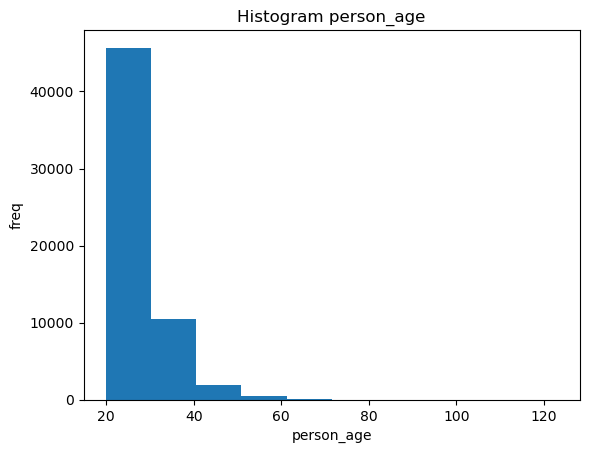

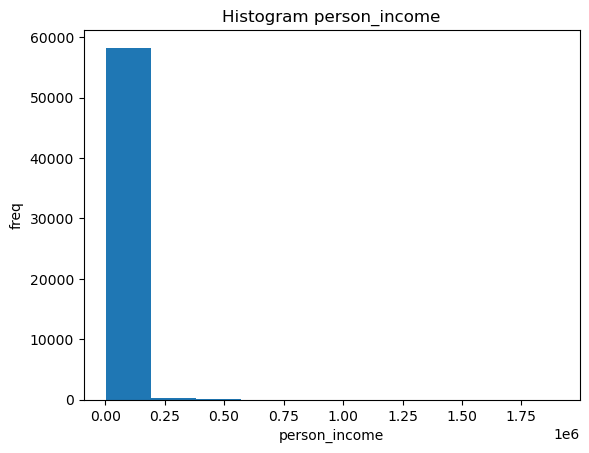

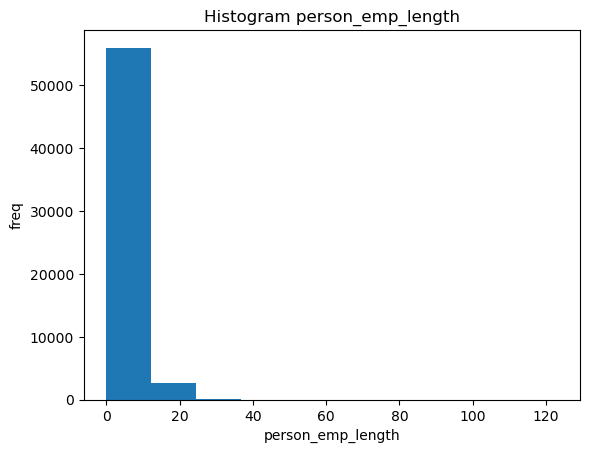

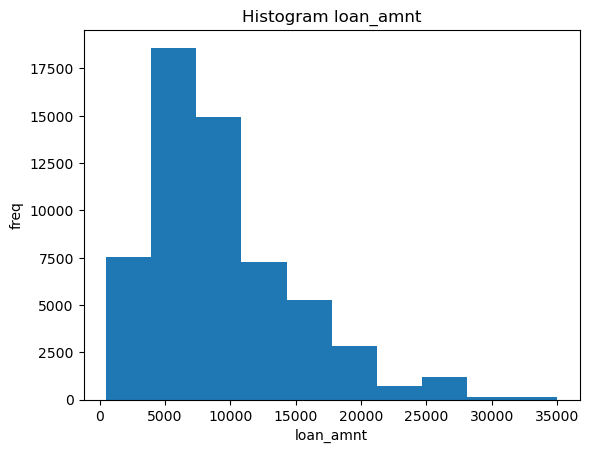

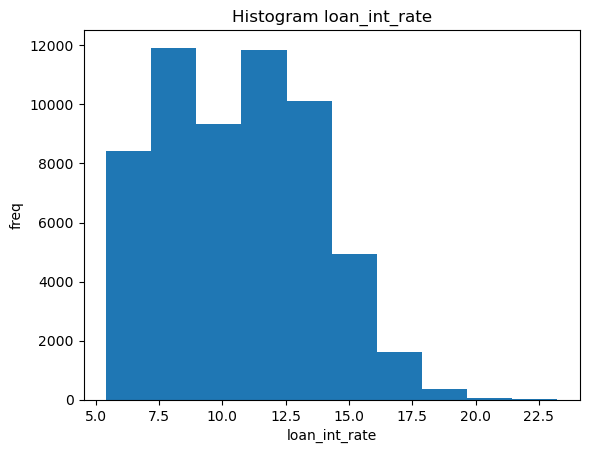

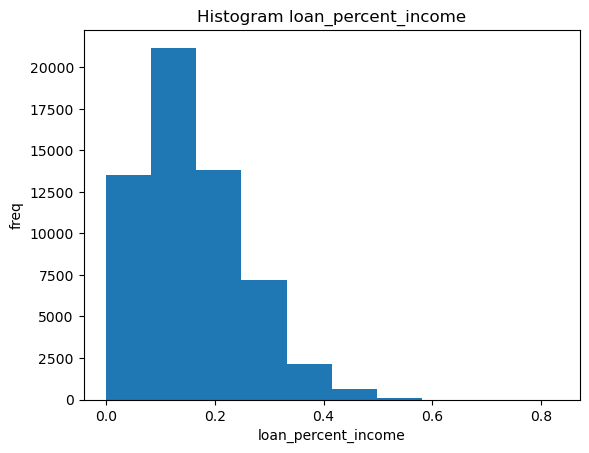

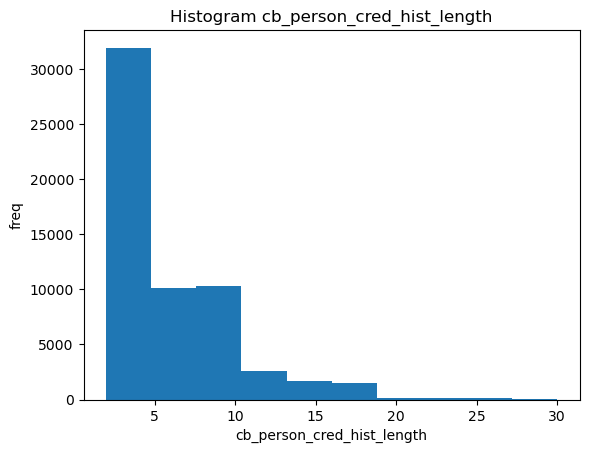

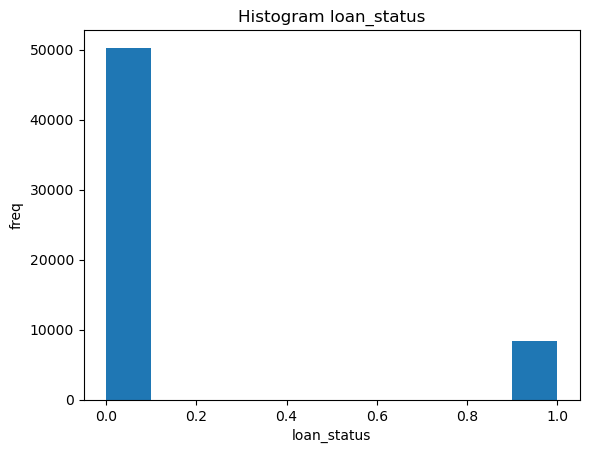

In [91]:
numerical = df.select_dtypes(include=np.number)

for col in numerical :
    plt.hist(df[col])
    plt.xlabel(col)
    plt.ylabel("freq")
    plt.title(f"Histogram {col}")
    plt.show()
    plt.close()

We can see that we have some sort of data imbalance for our independent variable (loan status).

In [92]:
loan_true = len(df[df["loan_status"] == 1])
loan_false = len(df[df["loan_status"] == 0])

loan_true_rate = loan_true/len(df)
loan_false_rate = loan_false/len(df)

print(loan_true_rate, loan_false_rate)

0.14238212976383324 0.8576178702361668


### We have a 14 : 86 imbalance ratio

So i have some planning to make 3 preprocessed data versions :
    
    a. no smote
    b. undersampling
    c. oversampling
    d. hybrid

And for all those 3 preprocessed data, i'll try  class_weight for None and "balance".

After that i will compare the evaluation metrics and decide which one is the best model.

# Bar chart for categorical data

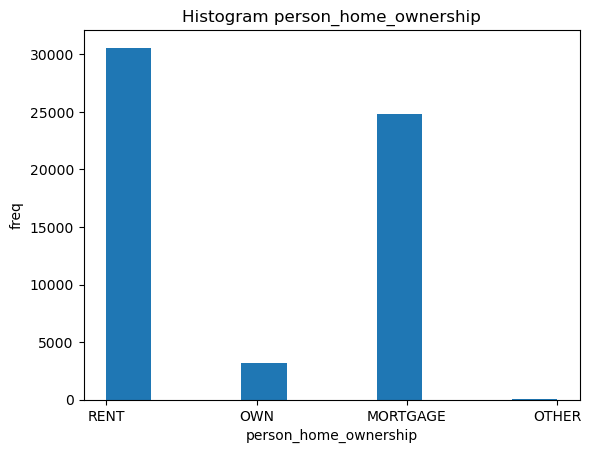

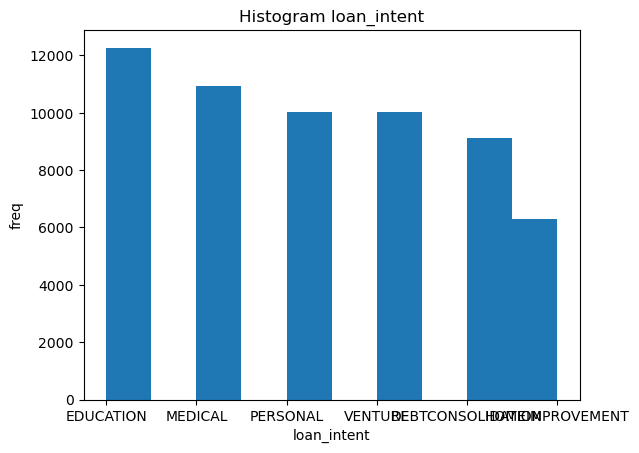

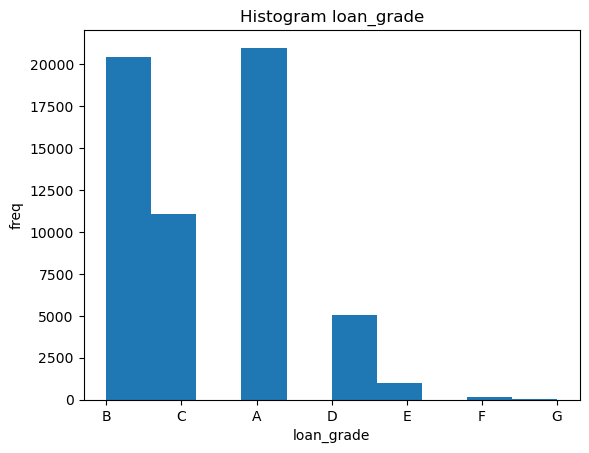

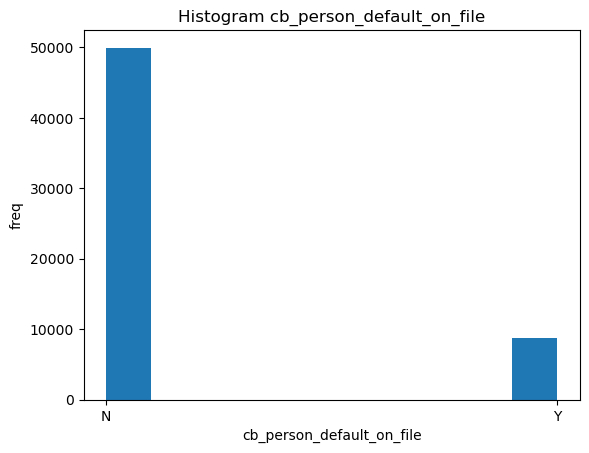

In [93]:
categorical = df.select_dtypes(exclude=np.number)

for col in categorical :
    plt.hist(df[col])
    plt.xlabel(col)
    plt.ylabel("freq")
    plt.title(f"Histogram {col}")
    plt.show()
    plt.close()

# Box plot for all columns

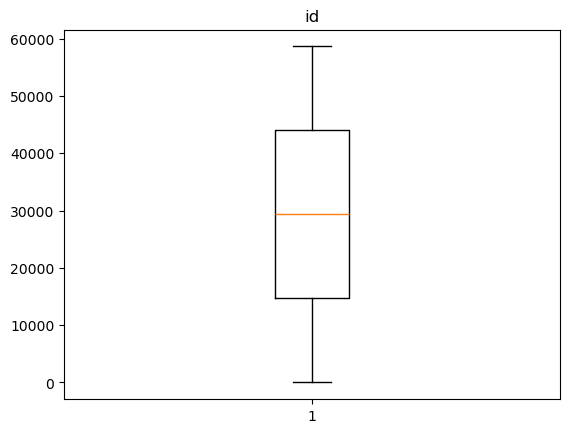

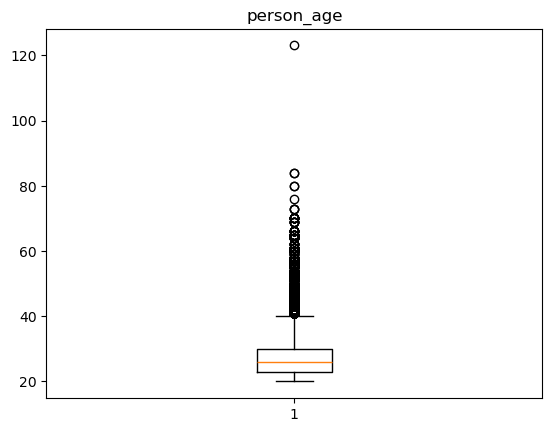

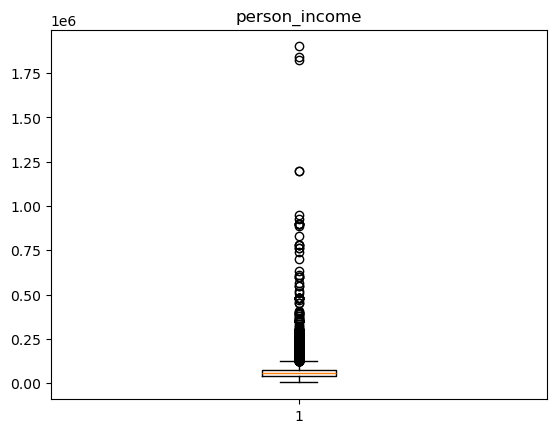

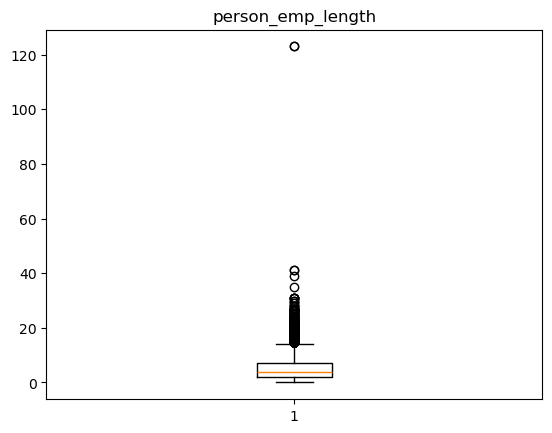

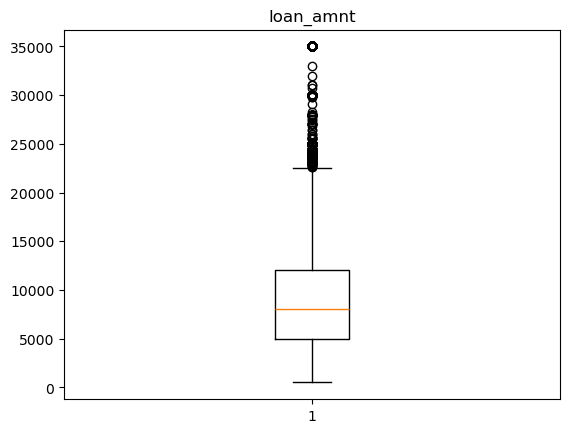

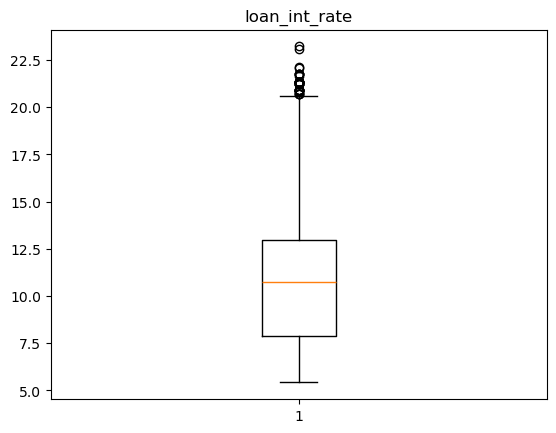

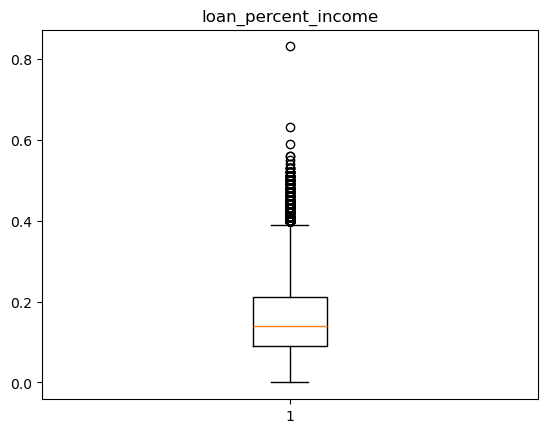

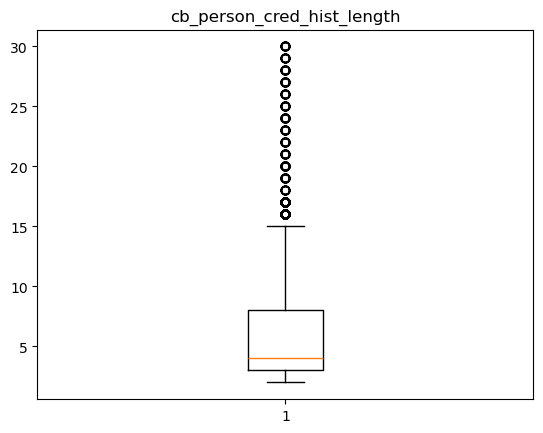

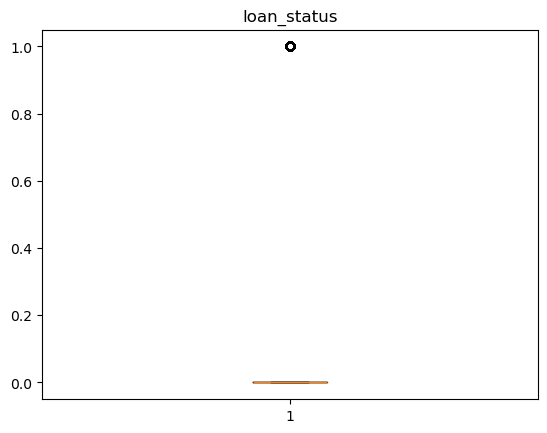

In [94]:
for col in df.select_dtypes(include='number').columns :
    plt.boxplot(df[col])
    plt.title(col)
    plt.show()

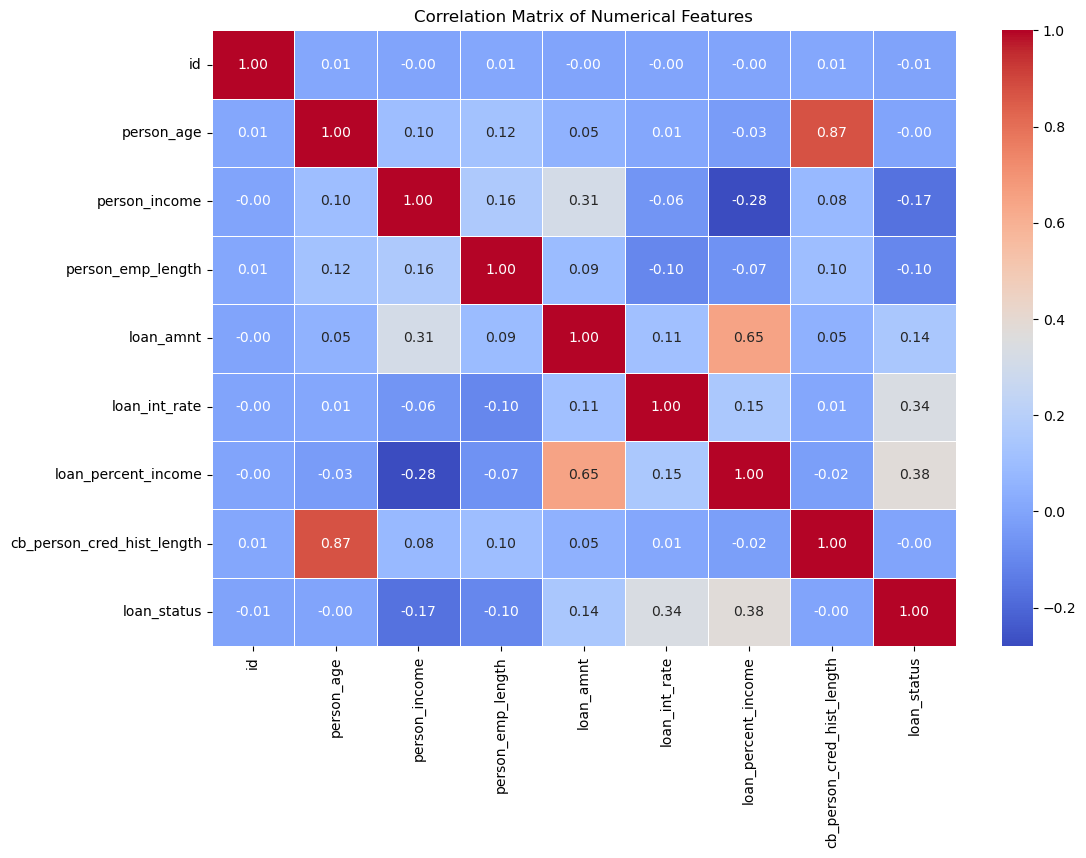

In [95]:
# Correlation Matrix Heatmap
plt.figure(figsize=(12, 8))
# Select only numerical columns for the correlation matrix
numerical_df = df.select_dtypes(include=np.number)
corr_matrix = numerical_df.corr()

# Plot the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()
plt.close()

In [96]:
df_processed = preprocess(df)
test_processed = preprocess(test)

In [97]:
df_processed.head()

,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,loan_status,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,0.0,5,6000,11.49,0.17,0,0,0,0,0,1,0,1,0,0,0,0
1,6.0,4,4000,13.35,0.07,0,0,0,0,1,0,0,0,0,1,0,0
2,8.0,6,6000,8.90,0.21,0,0,0,0,1,0,0,0,0,0,1,0
3,14.0,5,12000,11.11,0.17,0,0,0,0,0,1,0,0,0,0,0,1
4,2.0,6,6000,6.92,0.10,0,0,0,0,0,1,0,0,0,1,0,0


In [98]:
test_processed.head()

,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,3.0,1,25000,15.76,0.36,0,0,0,0,1,0,0,1,0,0,0
1,6.0,4,10000,12.68,0.10,1,1,0,0,0,0,0,0,0,1,0
2,5.0,2,4000,17.19,0.13,1,0,0,0,1,0,0,0,0,0,1
3,4.0,6,7000,8.90,0.14,0,0,0,0,1,1,0,0,0,0,0
4,8.0,3,15000,16.32,0.15,1,1,0,0,0,0,0,1,0,0,0


# SMOTE

### Variable separation

In [99]:
X = df_processed.drop(columns=["loan_status"])
y = df_processed["loan_status"]

## No sampling

In [100]:
X_no_sampling, y_no_sampling = X.copy(), y.copy()

## Oversampling

In [101]:
smote = SMOTE(random_state=42)
X_oversampling, y_oversampling = smote.fit_resample(X, y)

## Undersampling

In [102]:
rus = RandomUnderSampler(random_state=42)
X_undersampling, y_undersampling = rus.fit_resample(X, y)

## Hybrid

In [103]:
smt = SMOTETomek(random_state=42)
X_hybrid, y_hybrid = smt.fit_resample(X, y)

## Distribution check

In [104]:
for name, y_res in [("No Sampling", y_no_sampling), 
                     ("Oversampling", y_oversampling), 
                     ("Undersampling", y_undersampling), 
                     ("Hybrid", y_hybrid)]:
    total = len(y_res)
    pos = y_res.sum()
    print(f"{name}: total={total}, 0={total-pos}, 1={pos}, ratio={pos/total:.2f}")

No Sampling: total=58645, 0=50295, 1=8350, ratio=0.14
Oversampling: total=100590, 0=50295, 1=50295, ratio=0.50
Undersampling: total=16700, 0=8350, 1=8350, ratio=0.50
Hybrid: total=98626, 0=49313, 1=49313, ratio=0.50


In [105]:
weight = [None, "balanced"]

# Training and Fitting

## SVC model

In [106]:
X_train, X_val, y_train, y_val = train_test_split(X_no_sampling, y_no_sampling, shuffle=True, test_size=0.2, random_state=42)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', None),
    ('svm', SVC(kernel="rbf", class_weight=None, probability=False, random_state=42, C=0.5))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_val)
y_scores = pipeline.decision_function(X_val)

print(classification_report(y_val, y_pred))
print("AUC:", roc_auc_score(y_val, y_scores))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97     10087
           1       0.91      0.66      0.77      1642

    accuracy                           0.94     11729
   macro avg       0.93      0.82      0.87     11729
weighted avg       0.94      0.94      0.94     11729

AUC: 0.8919364681956382


# Logistic Regression CV

In [107]:
X_train, X_val, y_train, y_val = train_test_split(X_no_sampling, y_no_sampling, test_size=0.2, random_state=42, stratify=y_no_sampling)

pipeline = Pipeline([
    ('sampler', None),
    ('scaler', StandardScaler()),
    ('logisticcv', LogisticRegressionCV(Cs=100, cv=5, scoring="roc_auc", random_state=69, class_weight=None))
])

pipeline.fit(X_train, y_train)


y_pred = pipeline.predict(X_val)
y_scores = pipeline.decision_function(X_val)

print(classification_report(y_val, y_pred))
print("AUC:", roc_auc_score(y_val, y_scores))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94     10059
           1       0.75      0.46      0.57      1670

    accuracy                           0.90     11729
   macro avg       0.83      0.72      0.76     11729
weighted avg       0.89      0.90      0.89     11729

AUC: 0.8961447221870008


# Current BEST - Random Forest

In [108]:
X_train, X_val, y_train, y_val = train_test_split(
    X_no_sampling, y_no_sampling, 
    test_size=0.2, random_state=42, stratify=y_no_sampling
)

rf_pipeline = Pipeline([
    ('sampler', SMOTE(random_state=39)),
    ('scaler', StandardScaler()),
    ('randomforest', RandomForestClassifier(random_state=69, class_weight="balanced", n_estimators=100, max_depth=20, verbose=0))
])

# current best hyperparameter  : nestimators = 100, weightbalanced, maxdepth 20

rf_pipeline.fit(X_train, y_train)

y_pred = rf_pipeline.predict(X_val)
y_scores = rf_pipeline.predict_proba(X_val)[:, 1]

print(classification_report(y_val, y_pred))
print("AUC:", roc_auc_score(y_val, y_scores))



              precision    recall  f1-score   support

           0       0.95      0.98      0.97     10059
           1       0.88      0.71      0.79      1670

    accuracy                           0.95     11729
   macro avg       0.92      0.85      0.88     11729
weighted avg       0.94      0.95      0.94     11729

AUC: 0.9206121309424098


In [109]:
cm = confusion_matrix(y_val, y_pred)

print(cm)

[[9901  158]
 [ 477 1193]]


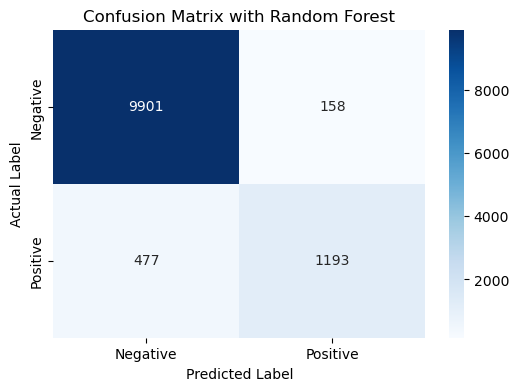

In [110]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix with Random Forest')
plt.show()

# Save the model

In [111]:
import joblib

joblib.dump(rf_pipeline, 'rf_loan_prediction.pkl')

['rf_loan_prediction.pkl']